## Wine Quality Dataset Analysis

Este análisis explora las características químicas de distintos vinos y su relación con la calidad evaluada por expertos.

El objetivo principal es comprender la estructura del dataset mediante técnicas de análisis exploratorio y métodos de aprendizaje no supervisado.

Se aplicarán tres enfoques principales:

1. Análisis exploratorio de datos (EDA)
2. Reducción de dimensionalidad mediante PCA
3. Agrupamiento de observaciones mediante K-Means

Estas técnicas permiten identificar patrones ocultos, relaciones entre variables y posibles agrupaciones naturales dentro del dataset.


------------

## Carga del dataset e inspección inicial

En esta sección se carga el dataset de calidad del vino y se revisa su estructura general.

El objetivo es confirmar que el archivo fue leído correctamente y verificar:

- número de filas y columnas,
- nombres de variables,
- valores faltantes,
- duplicados.

Esta revisión es importante antes de aplicar cualquier análisis estadístico o técnica de aprendizaje no supervisado.

In [1]:
from src.paquete_analisis_vino import AnalisisVino

analisis = AnalisisVino("data/raw/winequality-red.csv")

print(analisis.resumen_datos())

      métrica  valor
0     n_filas   1599
1  n_columnas     12
2  duplicados    240


**Inspección inicial**

El dataset contiene 1599 observaciones y 12 variables.
No se detectan valores nulos.

Existen 240 registros duplicados, los cuales se mantienen para conservar la estructura original del dataset.

In [2]:
analisis.nulos_por_columna()

,columna,nulos
0,fixed acidity,0
1,volatile acidity,0
2,citric acid,0
3,residual sugar,0
4,chlorides,0
5,free sulfur dioxide,0
6,total sulfur dioxide,0
7,density,0
8,pH,0
9,sulphates,0


**Revisión nulos**

Podemos ver que el dataset de vinos no tiene ningún valor nulo, esto es bueno, nos dice que no tendremos que
imputar o borrar datos.

In [3]:
analisis.estadisticas()

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


El método `estadisticas()` calcula las estadísticas descriptivas estándar para todas las variables numéricas: media, desviación estándar, mínimo, máximo y percentiles. Esta exploración cuantitativa permite identificar asimetrías, valores extremos y diferencias de escala entre variables, aspectos relevantes para el preprocesamiento posterior.

**Observación**

Las variables presentan escalas distintas, por lo que será necesario aplicar estandarización antes de los métodos de clustering. Esto se debe a que algoritmos como K-means o clustering jerárquico calculan distancias entre observaciones, y variables con rangos más amplios dominarían artificialmente esa medida. Al estandarizar, cada variable contribuye de forma equitativa al cálculo de similitud entre puntos.

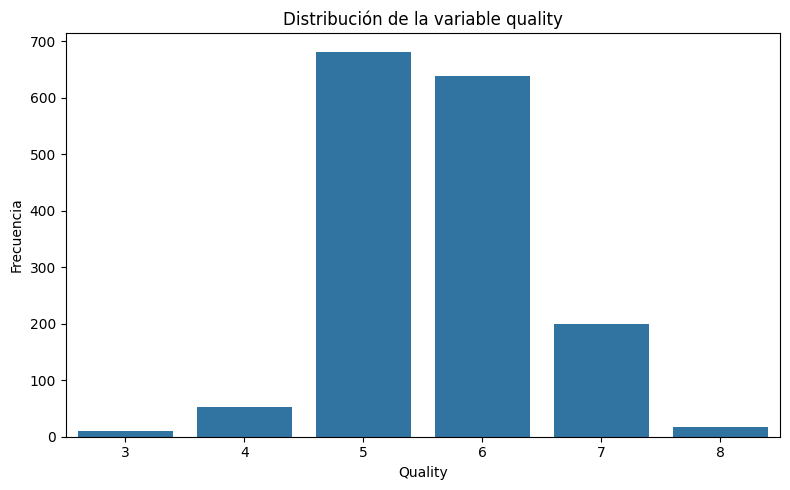

In [4]:
analisis.distribucion_quality()

Se visualiza la distribución de la variable quality, que será lo que posteriormente separaremos y usaremos las demás características para predecirla. Este gráfico permite evaluar si las clases están balanceadas o si existen concentraciones en algunos valores.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


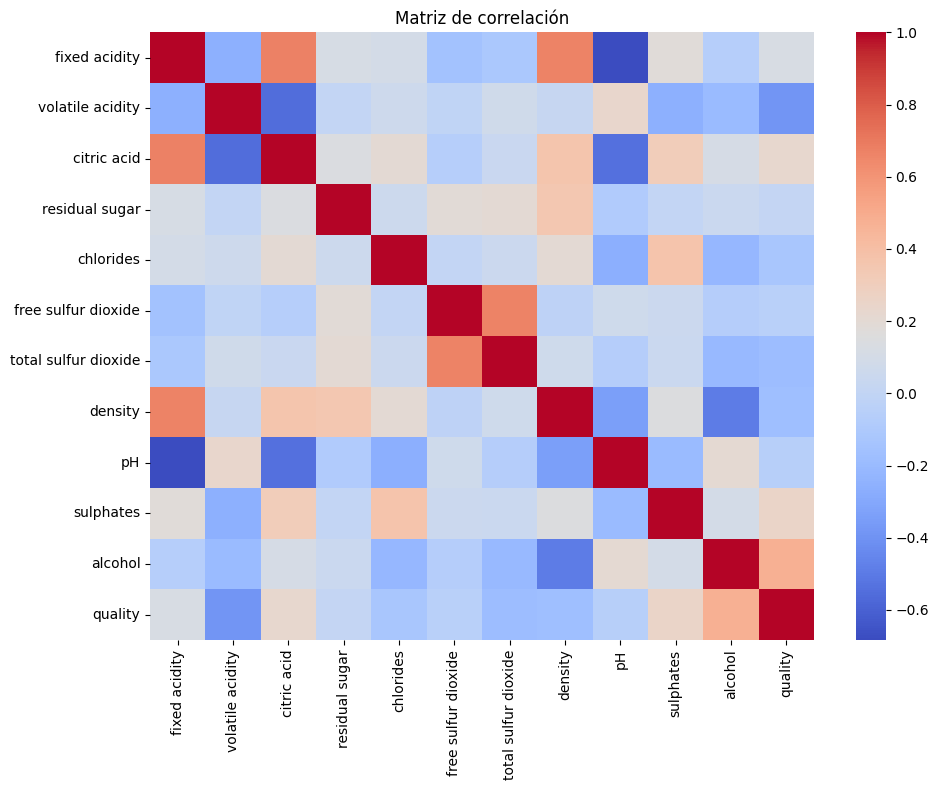

In [5]:
analisis.matriz_correlacion()

`matriz_correlacion()` Calcula la matriz de correlacion, esta matriz permite identificar relaciones lineales fuertes entre variables y anticipar cuáles atributos tienen mayor asociación con la calidad del vino. Lo podemos ver en el mapa de calor.

---



## Preparación de Datos

### Separar Quality

In [6]:
analisis.separar_quality()

separar_quality ejecutado correctamente — X: (1599, 11) | y: (1599,)


Se separa la variable `quality` del conjunto de variables de entrada antes de aplicar métodos no supervisados, ya que esta corresponde a la etiqueta o calificación real del vino. Si se incluyera dentro de las características, el algoritmo podría formar clusters utilizando directamente esa información, lo que distorsionaría la estructura real de los datos. Quality se almacena como `y`, y todas las demás variables se almacenan como `X`.

### Escalar variables

In [8]:
analisis.escalar_variables()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
...,...,...,...,...,...,...,...,...,...,...,...
1594,-1.217796,0.403229,-0.980669,-0.382271,0.053845,1.542054,-0.075043,-0.978765,0.899886,-0.461180,0.072294
1595,-1.390155,0.123905,-0.877968,-0.240375,-0.541259,2.211469,0.137820,-0.862162,1.353436,0.601055,0.729364
1596,-1.160343,-0.099554,-0.723916,-0.169427,-0.243707,1.255161,-0.196679,-0.533554,0.705508,0.542042,0.541630
1597,-1.390155,0.654620,-0.775267,-0.382271,-0.264960,1.542054,-0.075043,-0.676657,1.677400,0.305990,-0.209308


Se aplica estandarización, transformando cada variable para que tenga media cero y desviación estándar unitaria. Las variables presentan escalas distintas, por lo que esta normalización es necesaria antes de aplicar PCA y los algoritmos de clustering. Esto se debe a que métodos como K-means o clustering jerárquico calculan distancias entre observaciones, y variables con rangos más amplios dominarían artificialmente esa medida. Al estandarizar, cada variable contribuye de forma equitativa al cálculo de similitud entre puntos.

---

## Modelos



---

**1. PCA**

---

In [9]:
analisis.ejecutar_pca()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,-1.619530,0.450950,-1.774454,0.043740,0.067014,0.913921,0.161043,0.282258,-0.005098,-0.267759,0.048630
1,-0.799170,1.856553,-0.911690,0.548066,-0.018392,-0.929714,1.009829,-0.762587,0.520707,0.062833,-0.138142
2,-0.748479,0.882039,-1.171394,0.411021,-0.043531,-0.401473,0.539553,-0.597946,0.086857,-0.187442,-0.118229
3,2.357673,-0.269976,0.243489,-0.928450,-1.499149,0.131017,-0.344290,0.455375,-0.091577,-0.130393,0.316714
4,-1.619530,0.450950,-1.774454,0.043740,0.067014,0.913921,0.161043,0.282258,-0.005098,-0.267759,0.048630
...,...,...,...,...,...,...,...,...,...,...,...
1594,-2.150500,0.814286,0.617063,0.407687,-0.240936,-0.054835,-0.170812,0.355866,0.971524,0.356851,-0.053382
1595,-2.214496,0.893101,1.807402,0.414003,0.119592,0.674711,0.607970,0.247640,1.058135,0.478879,-0.241258
1596,-1.456129,0.311746,1.124239,0.491877,0.193716,0.506410,0.231082,-0.079382,0.808773,0.242248,-0.402910
1597,-2.270518,0.979791,0.627965,0.639770,0.067735,0.860408,0.321487,0.468876,0.612248,0.779404,0.040923


El `Principal Component Analysis` o `PCA` se aplica sobre las variables estandarizadas para reducir la dimensionalidad del dataset; esto se refiere al número de componentes utilizados para representar los datos. Cada componente principal es una combinación lineal de las variables originales, construida de forma que capture la mayor varianza posible. Al proyectar los datos en este nuevo espacio, se eliminan redundancias entre variables correlacionadas y se retiene la información más relevante en un número reducido de ejes. Esto facilita tanto la visualización como el desempeño de los algoritmos de clustering, que operan de forma más eficiente en espacios de menor dimensión.

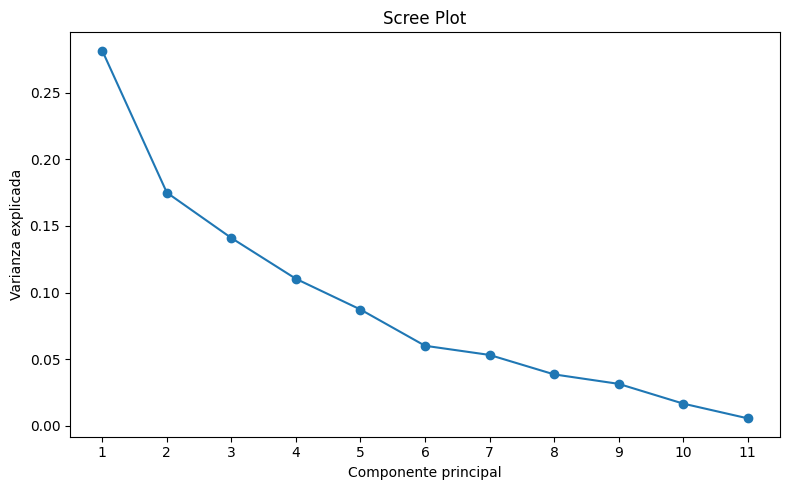

In [10]:
analisis.scree_plot()

**Observación**

Podemos ver que `PC1` explica el 28% de la varianza, `PC2`, `PC3` hacen que esto suba a casi 60% y luego de `PC4` la caída es menor, esto nos dice que podríamos explicar el dataset usando solo 5 o 6 columnas, en vez de las 11 que tenemos actualmente. De esta forma se reduciría la dimensionalidad, lo que busca lograr `PCA`.

In [11]:
analisis.pca_loadings()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
fixed acidity,0.489314,-0.110503,-0.123302,-0.229617,-0.082614,-0.101479,0.350227,0.177595,0.194021,-0.249523,0.639691
volatile acidity,-0.238584,0.274930,-0.449963,0.078960,0.218735,-0.411449,0.533735,0.078775,-0.129110,0.365925,0.002389
citric acid,0.463632,-0.151791,0.238247,-0.079418,-0.058573,-0.069593,-0.105497,0.377516,-0.381450,0.621677,-0.070910
residual sugar,0.146107,0.272080,0.101283,-0.372793,0.732144,-0.049156,-0.290663,-0.299845,0.007523,0.092872,0.184030
chlorides,0.212247,0.148052,-0.092614,0.666195,0.246501,-0.304339,-0.370413,0.357009,0.111339,-0.217671,0.053065
free sulfur dioxide,-0.036158,0.513567,0.428793,-0.043538,-0.159152,0.014000,0.116596,0.204781,0.635405,0.248483,-0.051421
total sulfur dioxide,0.023575,0.569487,0.322415,-0.034577,-0.222465,-0.136308,0.093662,-0.019036,-0.592116,-0.370750,0.068702
density,0.395353,0.233575,-0.338871,-0.174500,0.157077,0.391152,0.170481,0.239223,0.020719,-0.239990,-0.567332
pH,-0.438520,0.006711,0.057697,-0.003788,0.267530,0.522116,0.025138,0.561391,-0.167746,-0.010970,0.340711
sulphates,0.242921,-0.037554,0.279786,0.550872,0.225962,0.381263,0.447469,-0.374604,-0.058367,0.112320,0.069555


`pca_loadings()` muestra la contribución de cada variable original a cada componente, lo que permite interpretar qué atributos fisicoquímicos definen cada eje.

**Observación**

La tabla de loadings muestra la contribución de cada variable original a cada componente principal. En PC1, las variables con mayor peso son `fixed acidity` (0.49), `citric acid` (0.46) y `pH` (-0.44), lo que sugiere que este primer componente captura principalmente la acidez del vino en sus distintas formas. En PC2 destacan `total sulfur dioxide` (0.57) y `free sulfur dioxide` (0.51), indicando que este componente refleja el contenido de sulfitos. A partir de PC3 las contribuciones se distribuyen de forma más dispersa entre variables, lo que es consistente con la caída gradual observada en el scree plot y confirma que no existe una estructura dimensional muy concentrada en los datos.

,PC1,PC2
0,-1.619530,0.450950
1,-0.799170,1.856553
2,-0.748479,0.882039
3,2.357673,-0.269976
4,-1.619530,0.450950
...,...,...
1594,-2.150500,0.814286
1595,-2.214496,0.893101
1596,-1.456129,0.311746
1597,-2.270518,0.979791


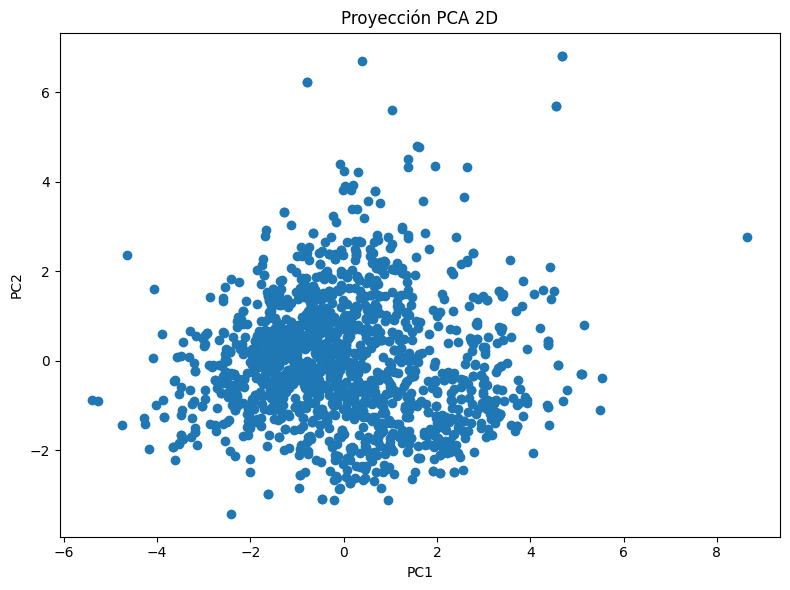

In [12]:
analisis.scatter_pca()

**Observación**

La proyección sobre las dos primeras componentes principales muestra los puntos bastante compactos y sin separaciones claras, lo que indica que los datos no forman grupos naturalmente distinguibles en este espacio reducido. La mayoría de los puntos están alrededor del origen, con una dispersión que se extiende ligeramente hacia valores positivos en PC1.La ausencia de estructura clara en esta proyección es consistente con lo observado en el scree plot: PC1 y PC2 juntos solo explican aproximadamente el 45% de la varianza total, por lo que esta vista bidimensional captura menos de la mitad de la información disponible.

---

**2. KMeans**

---

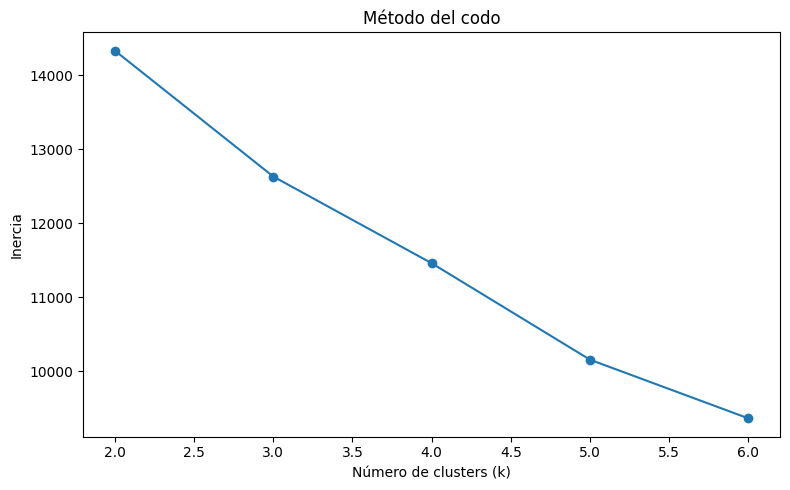

In [13]:
analisis.grafico_elbow()

**Observación**

El gráfico nos dice que 4 o 5 clusters son la mejor opción, porque las mejoras antes de 4 son bastante grandes y luego de 4 se vuelven mejoras mínimas. Se puede concluir que añadir más clusters no mejoraría la agrupación.

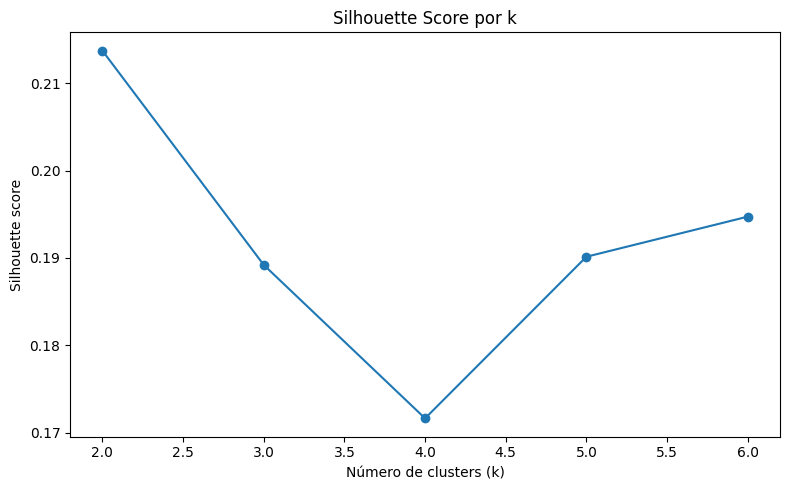

In [14]:
analisis.grafico_silhouette_kmeans()

In [15]:
analisis.evaluar_kmeans()

,k,inertia,silhouette_score
0,2,14330.119811,0.213730
1,3,12629.974592,0.189204
2,4,11459.143676,0.171636
3,5,10155.509585,0.190139
4,6,9363.206701,0.194729


K-means es un algoritmo de clustering particional que agrupa las observaciones en `k` clusters minimizando la inercia interna, es decir, la suma de distancias al cuadrado entre cada punto y el centroide de su cluster.

- `evaluar_kmeans()` calcula la inercia y el silhouette score para distintos valores de `k`, facilitando la selección del número óptimo de clusters.

In [16]:
analisis.ejecutar_kmeans()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_kmeans
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,2
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


In [17]:
analisis.comparar_kmeans_configuraciones()

,modelo,k,inertia,silhouette_score
0,kmeans_k2,2,14330.119811,0.213730
1,kmeans_k3,3,12629.974592,0.189204
2,kmeans_k4,4,11459.143676,0.171636
3,kmeans_k5,5,10155.509585,0.190139


**Observación**

Se evaluaron diferentes configuraciones de K-Means con valores de k entre 2 y 5. La inercia disminuye progresivamente conforme aumenta el número de clusters, lo cual es esperado. El silhouette score alcanza su valor máximo en k=2, aunque con una diferencia relativamente pequeña respecto a otros valores. Considerando además el método del codo, que sugiere k≈4, se puede concluir que el dataset presenta una estructura de agrupamiento moderada y que un número razonable de clusters se encuentra entre 2 y 4.

---

**3. HAC**

---

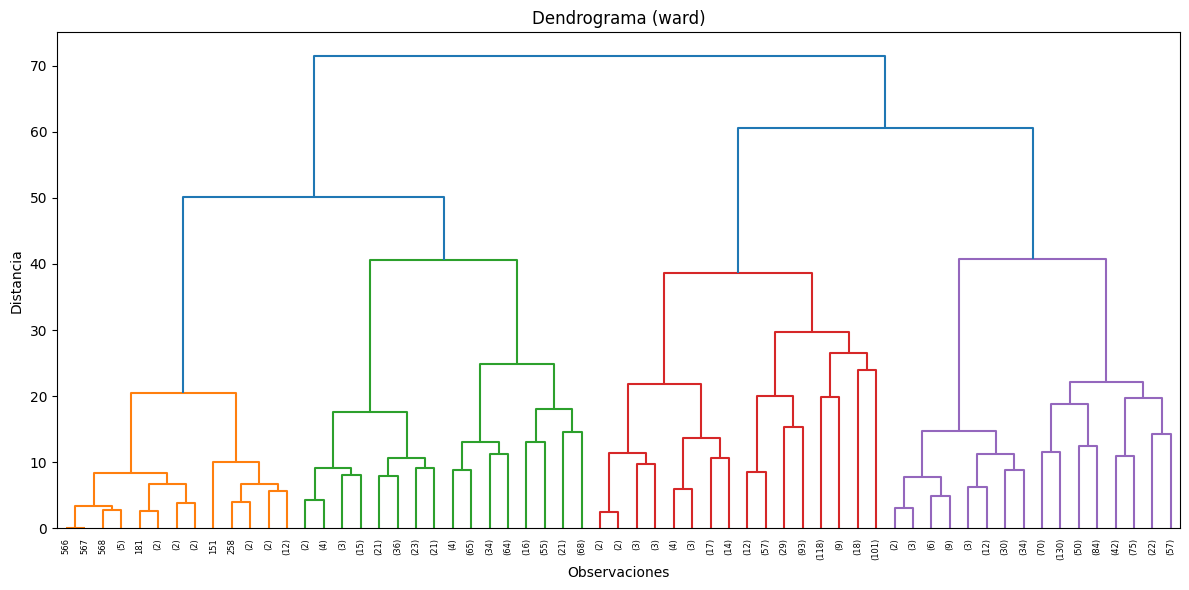

In [18]:
analisis.graficar_dendrograma()

El clustering jerárquico aglomerativo (HAC) construye una jerarquía de fusiones entre observaciones de forma ascendente, sin requerir especificar el número de clusters de antemano. El criterio de fusión (*linkage*) determina cómo se mide la distancia entre grupos.

**Observación**

El dendograma muestra varios niveles; podemos observar un salto bastante grande alrededor de 70, donde se separa en dos clusters principales. Pero si lo cortamos alrededor de 60 vemos que saltan 3 clusters principales y esta se vuelve la partición más interpretable.

Los números en la línea de `X` indican la cantidad de observaciones condensadas en cada nodo.


In [19]:
analisis.comparar_hac_configuraciones()

,modelo,linkage,n_clusters,silhouette_score
0,hac_ward,ward,3,0.157747
1,hac_complete,complete,3,0.355664
2,hac_average,average,3,0.563167


**Observación**

Al comparar tres configuraciones de clustering jerárquico utilizando los métodos de enlace `Ward`, `Complete` y `Average` con tres clusters; el método `Average` obtuvo el mejor score `0.563`, nos indica  que hay una separación clara entre clusters y una estructura de agrupamiento mejor que los otros métodos.

In [20]:
analisis.ejecutar_hac()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_hac
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


In [21]:
analisis.graficar_pairplot_hac()

---

**4. t-SNE**

---

In [22]:
analisis.comparar_tsne_configuraciones()

,modelo,perplexity,silhouette_score_2d
0,tsne_perplexity_5,5,0.379074
1,tsne_perplexity_30,30,0.411707
2,tsne_perplexity_50,50,0.439967


t-SNE es una técnica de reducción de dimensionalidad no lineal diseñada para visualización. A diferencia de PCA, preserva las relaciones de proximidad local entre observaciones, lo que la hace especialmente útil para explorar estructuras de cluster en espacios de alta dimensión.

El parámetro `perplexity` controla el balance entre estructura local y global: valores bajos capturan vecindades muy cercanas, mientras que valores altos consideran contextos más amplios. `comparar_tsne_configuraciones()` evalúa tres valores de perplejidad (5, 30 y 50) para identificar la configuración más informativa.

**Observación**

Las tres configuraciones evaluadas muestran un mejor score de silhouette según aumentamos `perplexity`. Esto nos dice que considerar aumentar el vecindario nos da proyecciones donde los clusters son más compactos y mejor separados.

In [23]:
analisis.ejecutar_tsne()

,TSNE1,TSNE2,quality
0,-41.728615,17.203728,5
1,-23.212732,32.961040,5
2,-23.067665,31.399397,5
3,36.067871,1.809033,6
4,-41.625431,17.541689,5
...,...,...,...
1594,-20.179478,-23.459818,5
1595,-15.748012,-22.750456,6
1596,-17.555283,-20.872335,6
1597,-19.749109,-25.959503,5


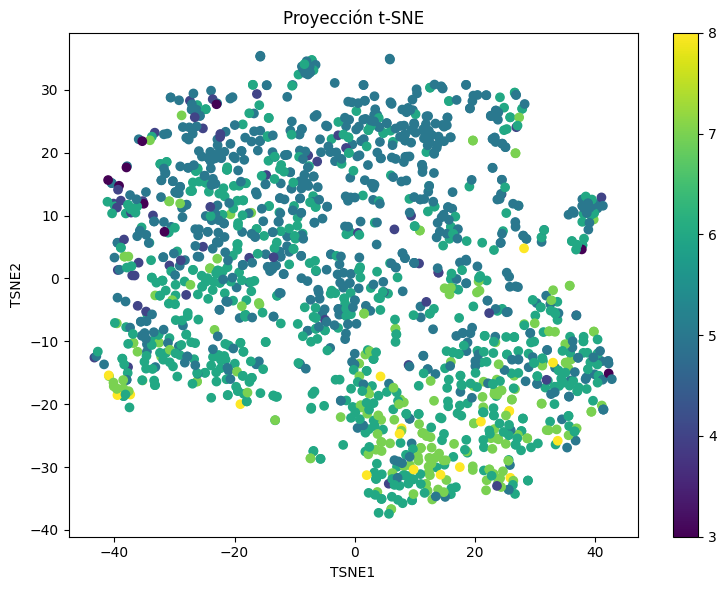

In [24]:
df_tsne = analisis.ejecutar_tsne(perplexity=50)
display(analisis.graficar_tsne(df_tsne))

**Observación**

La proyección t-SNE no revela agrupaciones claramente delimitadas por nivel de calidad. Los puntos se distribuyen de forma relativamente uniforme en el espacio, sin zonas exclusivas para ningún valor de `quality`. Sin embargo, se aprecia una tendencia leve: los vinos con calidad alta (tonos amarillo-verdosos, valores 7–8) aparecen ligeramente más concentrados en los bordes inferior y lateral derecho, mientras que los de calidad baja (tonos morados, valores 3–4) se dispersan de forma más aislada por el perímetro de la nube. La mayoría de las observaciones se agrupan en torno a calidades intermedias (5–6), lo que domina visualmente el gráfico y dificulta la separación. Esto sugiere que la calidad del vino **no está determinada por un patrón fisicoquímico simple y concentrado**, sino que emerge de combinaciones más sutiles entre variables.

---

**5. UMAP**

---

In [25]:
analisis.comparar_umap_configuraciones()

/Users/isaaccastillo/Documents/WineQuality-CastilloVega/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/isaaccastillo/Documents/WineQuality-CastilloVega/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/isaaccastillo/Documents/WineQuality-CastilloVega/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,modelo,n_neighbors,min_dist,silhouette_score_2d
0,umap_n10_d0.1,10,0.1,0.462663
1,umap_n15_d0.1,15,0.1,0.475046
2,umap_n30_d0.3,30,0.3,0.410843


UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensionalidad no lineal que, al igual que t-SNE, preserva la estructura local del espacio original, pero con la ventaja de ser más eficiente computacionalmente y de mantener mejor la estructura global.

Los parámetros clave son `n_neighbors`, que define el tamaño del vecindario local considerado, y `min_dist`, que controla qué tan compactos quedan los puntos en la proyección. `comparar_umap_configuraciones()` evalúa tres combinaciones de estos parámetros para seleccionar la representación más adecuada.

**Observación**

Las tres configuraciones evaluadas muestran silhouette scores similares, están entre 0.41 y 0.48. Pero al aumentar la cantidad de vecinos y la distancia mínima baja el score. Por eso se selecciona la opción 2 como la mejor, porque ofrece el mejor balance entre separación y cohesión.

/Users/isaaccastillo/Documents/WineQuality-CastilloVega/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


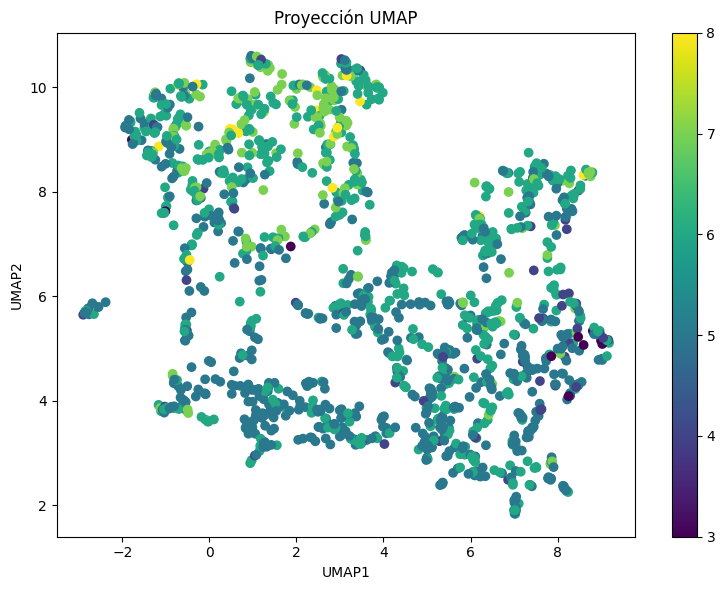

In [26]:
df_umap = analisis.ejecutar_umap(n_components=2, n_neighbors=15, min_dist=0.1)
display(analisis.graficar_umap(df_umap))

**Observación**

La proyección UMAP revela una estructura más articulada que la obtenida con t-SNE, mostrando subgrupos locales y ramificaciones que sugieren cierta organización interna en los datos. Sin embargo, al igual que en t-SNE, la separación por nivel de calidad no es limpia: los vinos de calidad alta (tonos amarillo-verdosos, 7–8) tienden a concentrarse en la región superior izquierda, mientras que los de calidad baja (tonos morados, 3–4) aparecen dispersos principalmente en los bordes inferiores y laterales. La mayoría de observaciones con calidad intermedia (5–6) dominan toda la proyección, dificultando una separación visual clara entre grupos.